# Práctica Votantes - Árboles & K-means

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [104]:
## Cargamos los datos

data = pd.read_excel(r"politicos.xlsx")

data.head()

,edad,ingresos,estudios,estado_civil,seguridad,impuestos,servicios_publicos,inmigracion,voto
0,61,1690,Postgraduate,Married,3,9,2,1,PP
1,26,1978,Basic,Divorced,1,5,9,1,PSOE
2,68,1547,Postgraduate,Widowed,9,9,10,2,PP
3,31,2937,University,Married,2,4,10,9,PSOE
4,43,2639,University,Divorced,7,1,1,9,VOX


In [105]:
data.describe(include="all")

,edad,ingresos,estudios,estado_civil,seguridad,impuestos,servicios_publicos,inmigracion,voto
count,3689.000000,3689.000000,3689,3689,3689.000000,3689.000000,3689.000000,3689.000000,3689
unique,NaN,NaN,3,4,NaN,NaN,NaN,NaN,3
top,NaN,NaN,Basic,Divorced,NaN,NaN,NaN,NaN,PP
freq,NaN,NaN,1269,979,NaN,NaN,NaN,NaN,2503
mean,48.663594,3015.001355,NaN,NaN,5.609650,5.554080,5.526159,5.494443,NaN
std,18.144033,1157.474329,NaN,NaN,2.865755,2.846272,2.890243,2.897664,NaN
min,18.000000,1000.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN
25%,33.000000,2023.000000,NaN,NaN,3.000000,3.000000,3.000000,3.000000,NaN
50%,48.000000,2999.000000,NaN,NaN,6.000000,6.000000,5.000000,5.000000,NaN
75%,64.000000,4022.000000,NaN,NaN,8.000000,8.000000,8.000000,8.000000,NaN


In [106]:
# Revisar si existen valores nulos

data.isnull().sum()

edad                  0
ingresos              0
estudios              0
estado_civil          0
seguridad             0
impuestos             0
servicios_publicos    0
inmigracion           0
voto                  0
dtype: int64

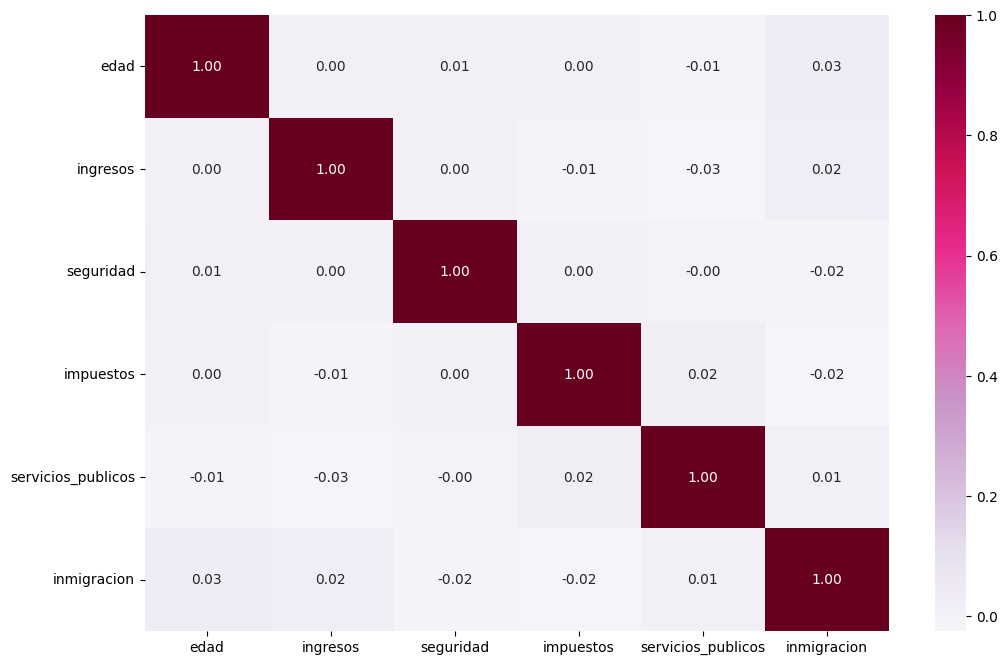

In [107]:
# Revisamos que correlación existe entre las variables

data.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap="PuRd",
            fmt=".2f")

plt.show()

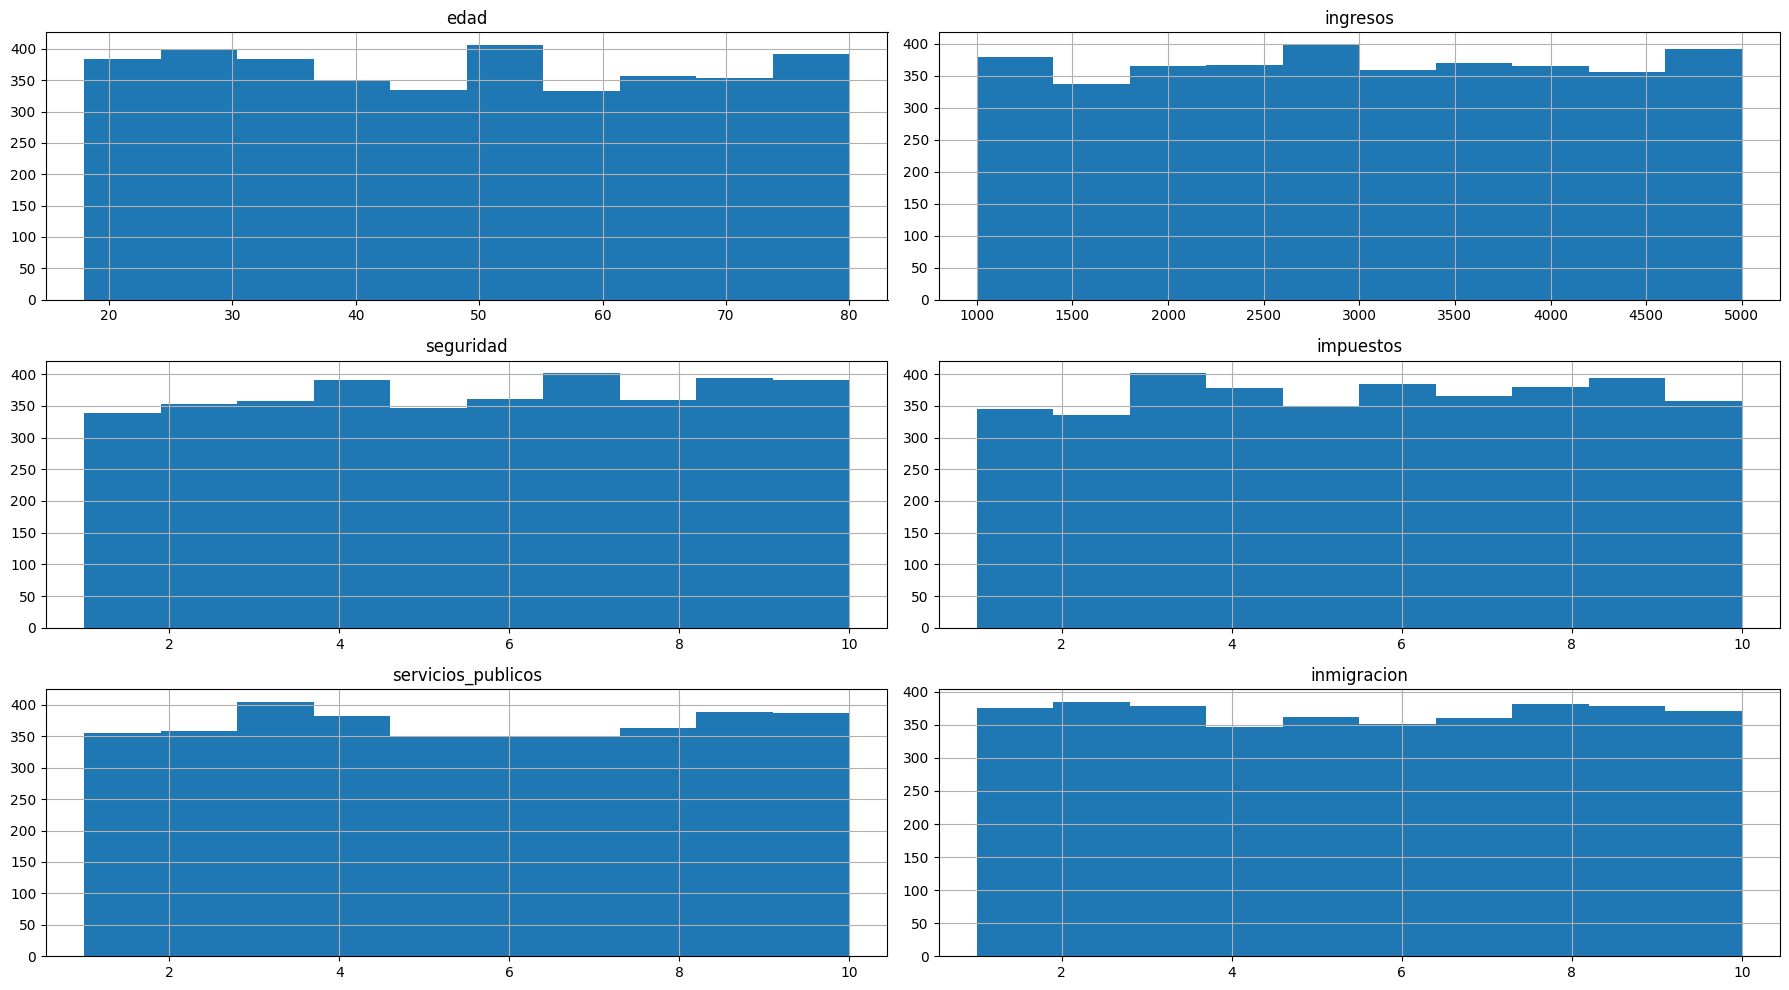

In [108]:
# Distribución de las variables

data.hist(figsize=(18, 10))

plt.tight_layout()
plt.show()

### 1. Modelos: Árbol de decisión + Random Forest + XGBoost

#### 1.1 Árbol de decisión

In [109]:
# Features (X): variables que el modelo usa para predecir
X = data[["edad", "ingresos", "seguridad", "impuestos", "servicios_publicos", "inmigracion"]]

# Target (y): lo que queremos predecir
# Partido político: PP,VOX,PSOE (Clsificamos 3)
y = data["voto"]

In [110]:
# Cómo está distribuido el target

print("Distribución del target:")
print(y.value_counts())
print(f"\nProporción: {y.value_counts(normalize=True).round(2).to_dict()}")

Distribución del target:
voto
PP      2503
VOX      602
PSOE     584
Name: count, dtype: int64

Proporción: {'PP': 0.68, 'VOX': 0.16, 'PSOE': 0.16}


In [111]:
# Entrenamiento (train/test)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 20% para test, 80% para entrenar
    stratify=y,          # mantiene la proporción de clases en ambos conjuntos
    random_state=42      # semilla para reproducibilidad
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 2951 muestras
Test:  738 muestras


In [112]:
# Entrenamiento del modelo

tree = DecisionTreeClassifier(max_depth=4, 
                              random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

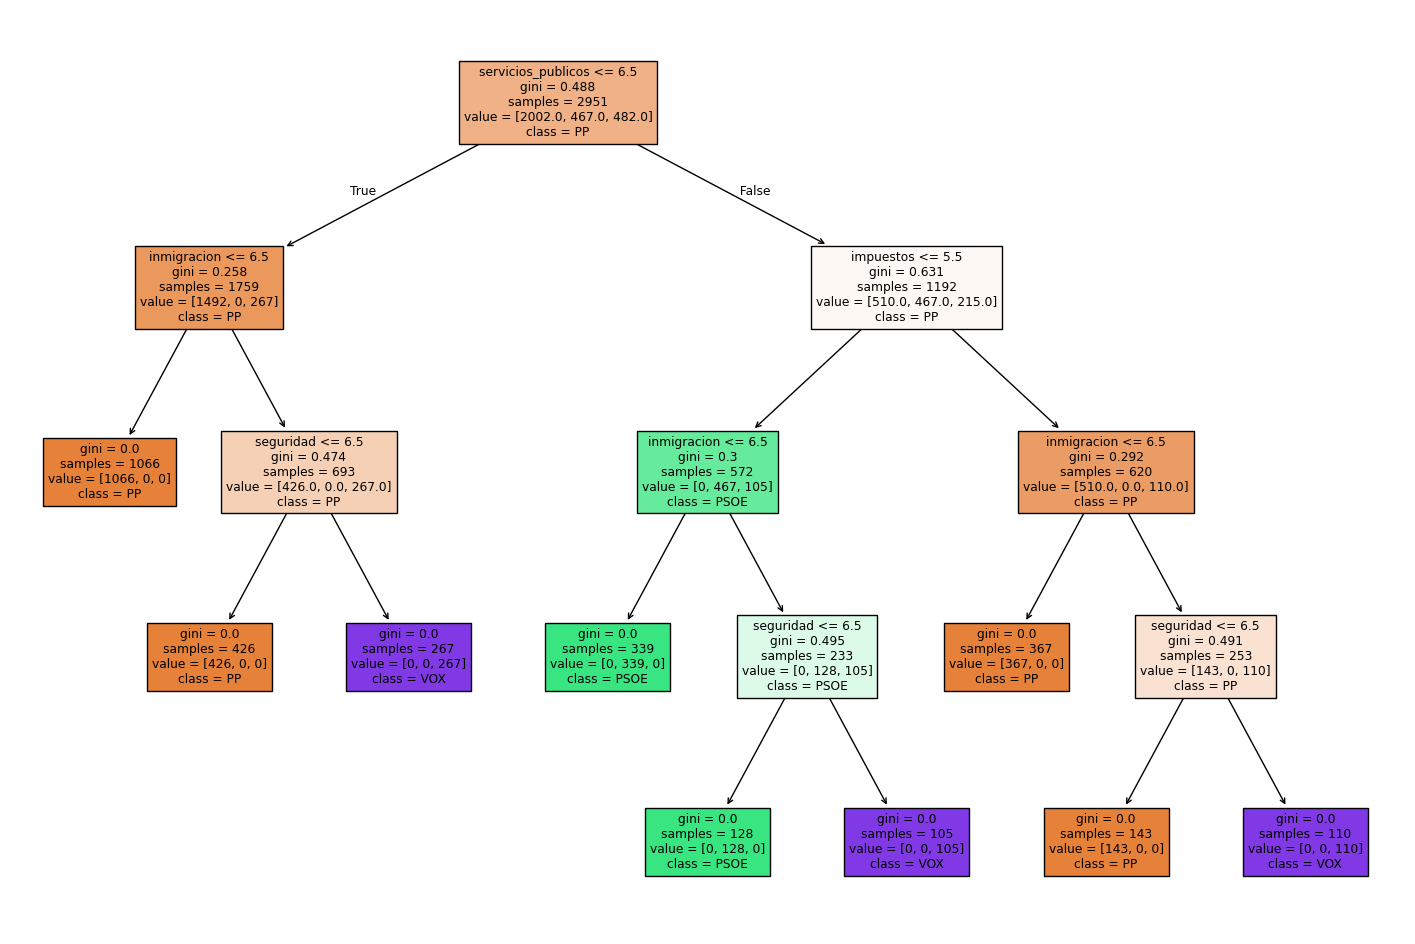

In [113]:
#Visualizar el árbol de decisión

plt.figure(figsize=(18, 12))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["PP", "PSOE", "VOX"],
    filled=True
)

plt.show()

In [114]:
# Evaluar el modelo

print("Arbol de decisión - Métricas de evaluación")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree, target_names=["PP", "PSOE","VOX"]))

Arbol de decisión - Métricas de evaluación
Accuracy: 1.0
Matriz de confusión:
[[501   0   0]
 [  0 117   0]
 [  0   0 120]]
              precision    recall  f1-score   support

          PP       1.00      1.00      1.00       501
        PSOE       1.00      1.00      1.00       117
         VOX       1.00      1.00      1.00       120

    accuracy                           1.00       738
   macro avg       1.00      1.00      1.00       738
weighted avg       1.00      1.00      1.00       738



In [115]:
# Importancia o contribución de cada variable individual

importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": tree.feature_importances_
}).sort_values(by="importance", ascending=False)
print(importances)

              feature  importance
2           seguridad    0.394375
3           impuestos    0.277490
5         inmigracion    0.164833
4  servicios_publicos    0.163302
1            ingresos    0.000000
0                edad    0.000000


### Random Forest

In [116]:
# Modelo random forest 

rf = RandomForestClassifier(
    n_estimators=200, 
    random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [117]:
y_pred_rf = rf.predict(X_test)

In [118]:
print("RANDOM FOREST - Métricas de evaluación")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=["PP", "VOX","PSOE"]))

RANDOM FOREST - Métricas de evaluación
Accuracy: 1.0
Matriz de confusión:
[[501   0   0]
 [  0 117   0]
 [  0   0 120]]
              precision    recall  f1-score   support

          PP       1.00      1.00      1.00       501
         VOX       1.00      1.00      1.00       117
        PSOE       1.00      1.00      1.00       120

    accuracy                           1.00       738
   macro avg       1.00      1.00      1.00       738
weighted avg       1.00      1.00      1.00       738



In [119]:
importances_rf = pd.DataFrame({
    "Feature":    X_train.columns,
    "Importancia": rf.feature_importances_
}).sort_values("Importancia", ascending=False)

print(importances_rf.to_string(index=False))

           Feature  Importancia
         seguridad     0.256724
servicios_publicos     0.241685
       inmigracion     0.234317
         impuestos     0.226994
          ingresos     0.023269
              edad     0.017012


### XGBOOST

In [129]:
from xgboost import XGBClassifier, plot_importance, plot_tree, to_graphviz
from sklearn.preprocessing import LabelEncoder          
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [130]:
#Transformar Y en PP(0), PSOE(1), VOX(2)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  
y_test_encoded  = label_encoder.transform(y_test) 

In [131]:
print("Clases aprendidas por el encoder:", label_encoder.classes_)

Clases aprendidas por el encoder: ['PP' 'PSOE' 'VOX']


In [132]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"   # ← CAMBIA: logloss es binario, mlogloss es multiclase
)

In [133]:
from sklearn.preprocessing import LabelEncoder


# Entrenamiento (encode the target variable)
xgb_model.fit(X_train, y_train_encoded)   # ← usa los labels codificados

# Predicción

y_pred_encoded = xgb_model.predict(X_test)

# Decode predictions back to original labels
y_pred = label_encoder.inverse_transform(y_pred_encoded)


In [134]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred, labels=label_encoder.classes_))
print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_   # ← orden automático del encoder, sin errores
))

Accuracy: 1.0

Matriz de confusión:
[[501   0   0]
 [  0 117   0]
 [  0   0 120]]

Reporte de clasificación:
              precision    recall  f1-score   support

          PP       1.00      1.00      1.00       501
        PSOE       1.00      1.00      1.00       117
         VOX       1.00      1.00      1.00       120

    accuracy                           1.00       738
   macro avg       1.00      1.00      1.00       738
weighted avg       1.00      1.00      1.00       738



c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 5000x3000 with 0 Axes>

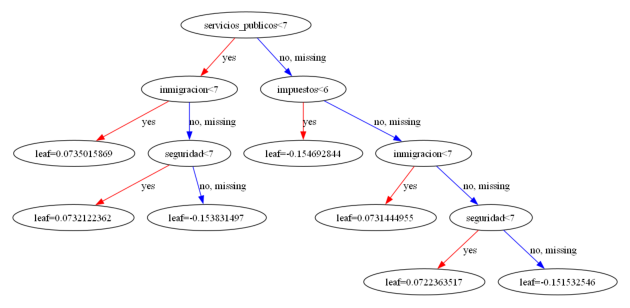

In [135]:
# Visualización

plt.figure(figsize=(50, 30))
plot_tree(xgb_model, num_trees=0)
plt.tight_layout()
plt.show()

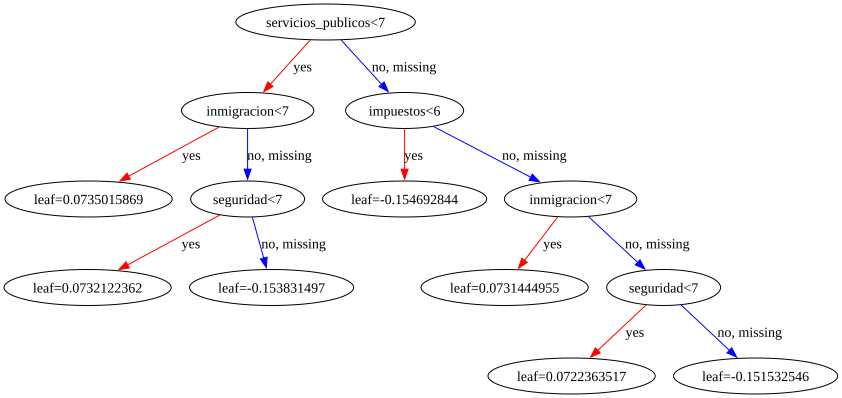

In [136]:
from xgboost import to_graphviz

graph = to_graphviz(xgb_model, num_trees=0)
graph  # ← esta línea es obligatoria en Jupyter para que se renderice

🟠
Votante PP
2.503 votantes · 67,9% del electorado
Servicios públicos
≤ 6.5 / 10
Inmigración
Moderada (≤ 6.5)
Impuestos
Rechazo alto (> 5.5)
Seguridad
Moderada
Edad
Irrelevante
Ingresos
Irrelevantes
Regla maestra: Valora poco el papel del Estado en servicios públicos Y es moderado en inmigración. Si además rechaza subir impuestos → PP aunque valore los servicios.
Cluster K-Means dominante
Perfil ideológico: Centro-derecha. Prefiere menos Estado, menos impuestos. No tiene posición extrema en inmigración. El cluster más numeroso refleja la hegemonía del PP en el dataset.

🟢
Votante PSOE
584 votantes · 15,8% del electorado
Servicios públicos
> 6.5 / 10
Inmigración
Tolerante (≤ 6.5)
Impuestos
Acepta moderados (≤ 5.5)
Seguridad
Baja preocupación
Edad
Irrelevante
Ingresos
Irrelevantes
Regla maestra: Alta valoración de servicios públicos Y posición moderada en inmigración Y acepta un nivel moderado de impuestos para financiarlos.
Cluster K-Means secundario
Perfil ideológico: Centro-izquierda. Cree en el Estado como proveedor de servicios. Tolerante en inmigración. Acepta pagar impuestos como contrapartida de mejores servicios.

🟣
Votante VOX
602 votantes · 16,3% del electorado
Servicios públicos
Baja valoración (≤ 6.5)
Inmigración
Posición dura (> 6.5)
Seguridad
Alta preocupación (> 6.5)
Impuestos
Variable
Edad
Irrelevante
Ingresos
Irrelevantes
Regla maestra: La inmigración es el denominador común. Aparece en TODOS los caminos hacia VOX. Alta preocupación por seguridad es el segundo factor diferenciador absoluto.
Cluster K-Means terciario
Perfil ideológico: Derecha identitaria. La inmigración y la seguridad son sus ejes principales. El nivel de ingresos y la edad no predicen su voto — es una posición ideológica, no económica.